**Análise de Variáveis Meteorológicas de Macau e Mossoró**

Neste relatório, faremos uma análise do banco de dados meteorológico contém registros mensais ao longo de 30 anos (1990 a 2019) para as cidades de Macau e Mossoró, no estado do Rio Grande do Norte. As variáveis analisadas são:

- Temperatura média (°C)
- Precipitação (mm)
- Radiação solar (MJ/m²)
- Umidade relativa do ar (%)

Importação das bibliotecas necessárias

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Preparação do Ambiente e Limpeza

In [21]:
# Definindo nomes claros para as colunas com base no cabeçalho do arquivo
cols = ['Data', 'Macau_Prec', 'Macau_UR', 'Macau_Temp', 'Macau_Rad',
        'Mossoro_Prec', 'Mossoro_UR', 'Mossoro_Temp', 'Mossoro_Rad', 'Extra1', 'Extra2']

# Lendo o CSV e ignorando as 2 primeiras linhas (cabeçalho duplo desconfigurado)
df = pd.read_csv('/content/BD_Macau_e_Mossor.csv', skiprows=2, names=cols, encoding='utf-8')

# Removendo colunas fantasmas geradas por vírgulas sobrando no CSV
df = df.drop(columns=['Extra1', 'Extra2'], errors='ignore')

# Corrigindo o separador decimal brasileiro (vírgula por ponto) e convertendo para número
colunas_numericas = df.columns[1:]
for col in colunas_numericas:
    df[col] = df[col].astype(str).str.replace('"', '').str.replace(',', '.').astype(float)

# Ajustando a coluna de Data para termos os Meses e Anos separados numericamente
meses_pt = {'jan.': 1, 'fev.': 2, 'mar.': 3, 'abr.': 4, 'mai.': 5, 'jun.': 6,
            'jul.': 7, 'ago.': 8, 'set.': 9, 'out.': 10, 'nov.': 11, 'dez.': 12}

df['Mes_Str'] = df['Data'].str.split('-').str[0]
df['Mes'] = df['Mes_Str'].map(meses_pt)

# Regra para mapear o ano (ex: 90 -> 1990; 19 -> 2019)
df['Ano_Str'] = df['Data'].str.split('-').str[1].astype(int)
df['Ano'] = df['Ano_Str'].apply(lambda x: 1900 + x if x >= 90 else 2000 + x)
df = df.drop(columns=['Mes_Str', 'Ano_Str'])

print("Dados carregados com sucesso! Dimensões do dataset:", df.shape)
display(df.head())

Dados carregados com sucesso! Dimensões do dataset: (360, 11)


,Data,Macau_Prec,Macau_UR,Macau_Temp,Macau_Rad,Mossoro_Prec,Mossoro_UR,Mossoro_Temp,Mossoro_Rad,Mes,Ano
0,jan.-90,14.73,53.258710,27.925806,35.250000,25.11,72.712903,27.029355,34.858710,1,1990
1,fev.-90,115.02,64.296071,27.100000,35.894286,61.14,75.856071,27.008929,35.556786,2,1990
2,mar.-90,60.74,62.428710,27.263548,34.995806,27.26,74.144839,27.574516,35.516129,3,1990
3,abr.-90,141.18,67.546333,27.075000,35.516333,111.66,75.700333,27.670000,35.766667,4,1990
4,mai.-90,45.02,66.114839,26.449032,34.641290,120.99,78.406774,26.819032,35.322258,5,1990


**1. Sazonalidade**

Nesta primeira parte do relatório iremos realizar as seguintes análises:

a) Analise o comportamento mensal das variáveis ao longo do ano para cada cidade.

b) Identifique os padrões sazonais (períodos mais secos, mais chuvosos, mais quentes, etc.).

c) Em quais meses ocorrem os valores máximos e mínimos de cada variável?

d) Compare a sazonalidade entre Macau e Mossoró. Quais são as principais semelhanças e diferenças?

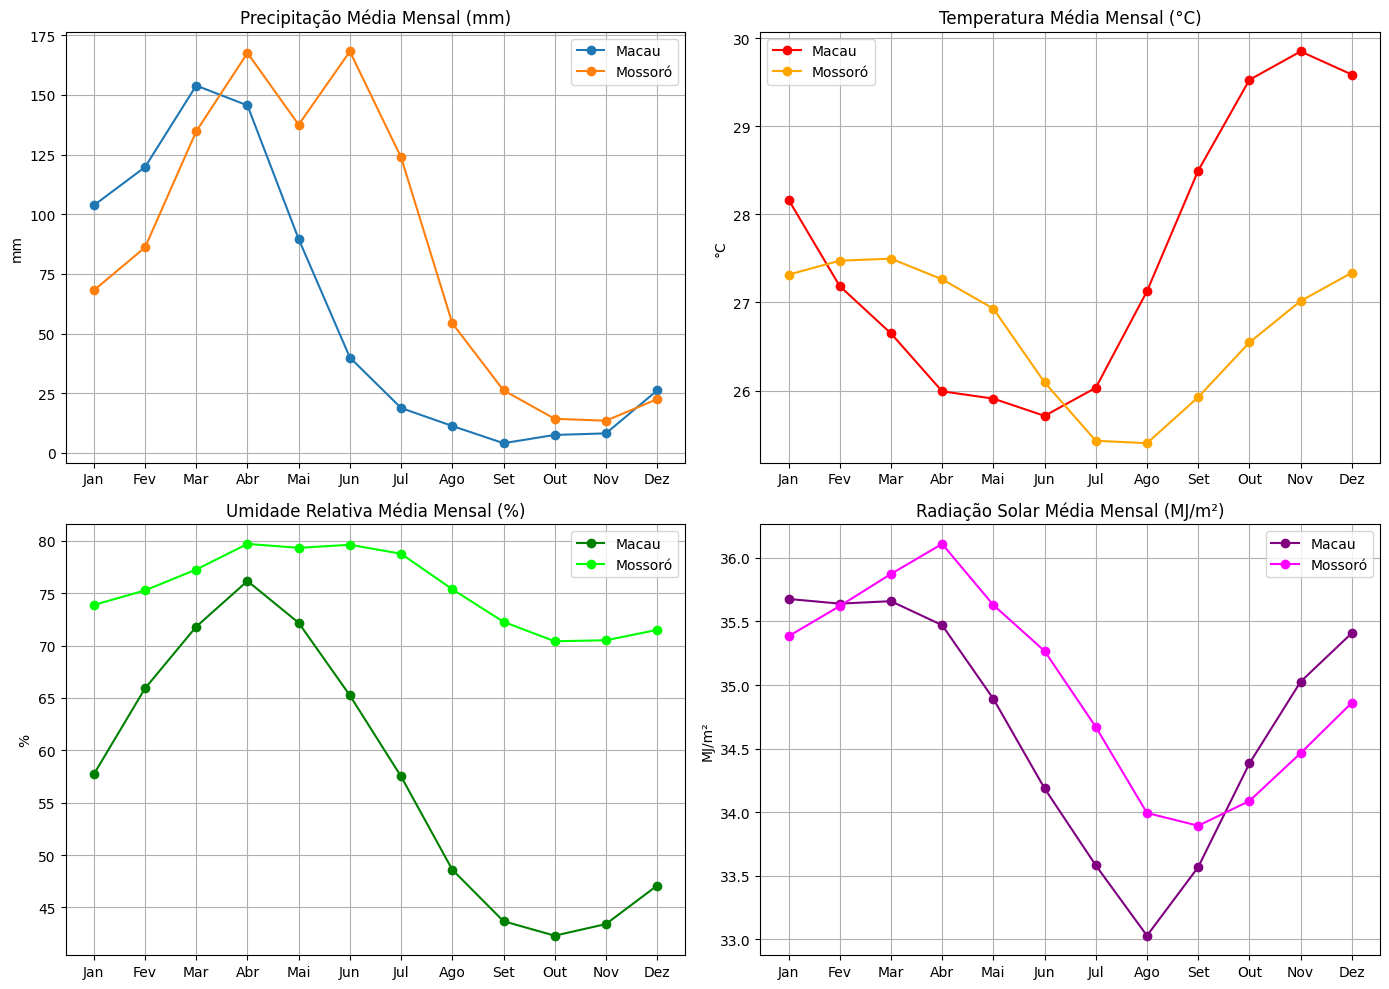


--- Valores Máximos e Mínimos Mensais ---


,Máximo,Mínimo
Macau_Prec,153.88 (Mar),4.09 (Set)
Macau_UR,76.17 (Abr),42.30 (Out)
Macau_Temp,29.85 (Nov),25.71 (Jun)
Macau_Rad,35.68 (Jan),33.03 (Ago)
Mossoro_Prec,168.18 (Jun),13.50 (Nov)
Mossoro_UR,79.72 (Abr),70.42 (Out)
Mossoro_Temp,27.50 (Mar),25.40 (Ago)
Mossoro_Rad,36.11 (Abr),33.89 (Set)


In [22]:
# Agrupando pelo mês e tirando a média das variáveis
sazonalidade = df.groupby('Mes').mean(numeric_only=True).reset_index()
meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

# Gerando a figura com 4 gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Precipitação
axes[0, 0].plot(meses_nomes, sazonalidade['Macau_Prec'], label='Macau', marker='o')
axes[0, 0].plot(meses_nomes, sazonalidade['Mossoro_Prec'], label='Mossoró', marker='o')
axes[0, 0].set_title('Precipitação Média Mensal (mm)')
axes[0, 0].set_ylabel('mm')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Temperatura
axes[0, 1].plot(meses_nomes, sazonalidade['Macau_Temp'], label='Macau', marker='o', color='red')
axes[0, 1].plot(meses_nomes, sazonalidade['Mossoro_Temp'], label='Mossoró', marker='o', color='orange')
axes[0, 1].set_title('Temperatura Média Mensal (°C)')
axes[0, 1].set_ylabel('°C')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Umidade Relativa (UR)
axes[1, 0].plot(meses_nomes, sazonalidade['Macau_UR'], label='Macau', marker='o', color='green')
axes[1, 0].plot(meses_nomes, sazonalidade['Mossoro_UR'], label='Mossoró', marker='o', color='lime')
axes[1, 0].set_title('Umidade Relativa Média Mensal (%)')
axes[1, 0].set_ylabel('%')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Radiação Solar
axes[1, 1].plot(meses_nomes, sazonalidade['Macau_Rad'], label='Macau', marker='o', color='purple')
axes[1, 1].plot(meses_nomes, sazonalidade['Mossoro_Rad'], label='Mossoró', marker='o', color='magenta')
axes[1, 1].set_title('Radiação Solar Média Mensal (MJ/m²)')
axes[1, 1].set_ylabel('MJ/m²')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Extraindo os valores Máximos e Mínimos para responder à Questão 1c
max_min = {}
colunas_analise = sazonalidade.columns[1:-1] # Exclui Mes e Ano
for col in colunas_analise:
    max_val, min_val = sazonalidade[col].max(), sazonalidade[col].min()
    max_mes = meses_nomes[sazonalidade[col].idxmax()]
    min_mes = meses_nomes[sazonalidade[col].idxmin()]
    max_min[col] = {'Máximo': f"{max_val:.2f} ({max_mes})", 'Mínimo': f"{min_val:.2f} ({min_mes})"}

df_max_min = pd.DataFrame(max_min).T
print("\n--- Valores Máximos e Mínimos Mensais ---")
display(df_max_min)

**Comportamento Mensal e Padrões Sazonais:**

Períodos mais chuvosos e úmidos: Estão totalmente concentrados no 1º semestre (destaque para o período de março a junho). A precipitação sobe vertiginosamente, puxando consigo a Umidade Relativa do ar.

Períodos mais secos: Consolidam-se a partir de agosto e duram por todo o 2º semestre. As chuvas despencam (para níveis abaixo de 15 mm mensais) e a umidade também cai drasticamente.

Períodos mais quentes e de maior radiação: Ocorrem justamente nos momentos de menor nebulosidade e chuva. Para Macau, o fim do ano (novembro/dezembro) é escaldante. Em ambas as cidades, a transição março/abril atinge altos níveis de radiação térmica.

**Mínimos e Máximos por Variável:**

- Macau:

  - Precipitação: Máx em Março (153.88 mm) | Mín em Setembro (4.09 mm).

  - Umidade Relativa: Máx em Abril (76.17%) | Mín em Outubro (42.30%).

  - Temperatura: Máx em Novembro (29.85°C) | Mín em Junho (25.71°C).

  - Radiação: Máx em Janeiro (35.68 MJ/m²) | Mín em Agosto (33.03 MJ/m²).

- Mossoró:

  - Precipitação: Máx em Junho (168.18 mm) | Mín em Novembro (13.50 mm).

  - Umidade Relativa: Máx em Abril (79.72%) | Mín em Outubro (70.42%).

  - Temperatura: Máx em Março (27.50°C) | Mín em Agosto (25.40°C).

  - Radiação: Máx em Abril (36.11 MJ/m²) | Mín em Setembro (33.89 MJ/m²).

**Semelhanças e Diferenças entre as cidades:**

Semelhanças: A sazonalidade é visualmente quase idêntica. Ambas possuem o mesmo regime de estações, sendo o primeiro semestre o polo das chuvas e o segundo semestre a estação da seca. Os picos e vales de umidade se alinham perfeitamente no calendário (máximas em abril, mínimas em outubro).

<br>

Diferenças: A Umidade Relativa de Macau tem uma amplitude enorme: sofre uma queda muito mais seca (vai de ~76% a ~42%), enquanto Mossoró se mantém úmida e mais estável o ano todo (cai apenas para ~70%).

<br>

Na Temperatura, Macau apresenta picos mais altos de calor no segundo semestre, atingindo quase 30°C na média, enquanto Mossoró é termicamente mais equilibrada e levemente mais amena.

<br>

Em Precipitação, Mossoró estende seu volume de águas intensamente até junho, ao passo que em Macau as chuvas perdem força notável após o pico de abril.

**Análise do Acumulado Anual:**

Acumulado de 30 anos (Precipitação e Radiação)

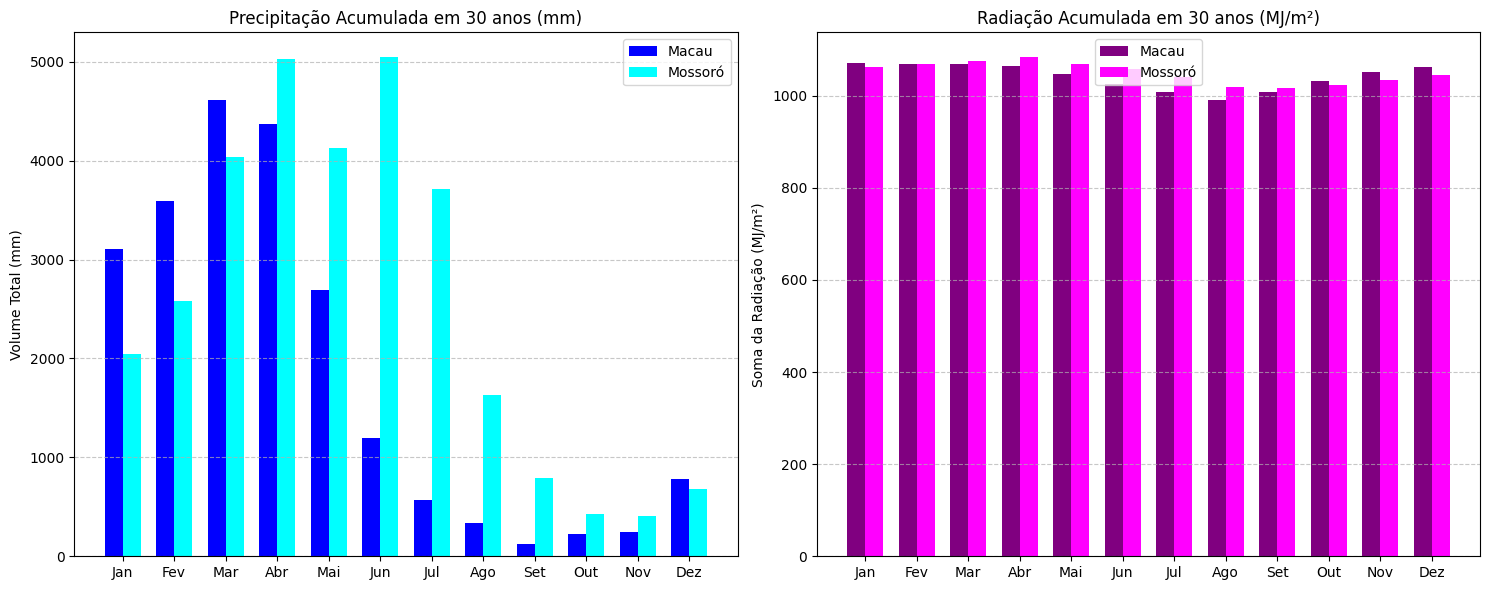


--- Valores Máximos e Mínimos ACUMULADOS em 30 anos ---


,Máx Acumulado,Mín Acumulado
Macau_Prec,4616.30 (Mar),122.61 (Set)
Macau_Rad,1070.30 (Jan),990.86 (Ago)
Mossoro_Prec,5045.28 (Jun),405.00 (Nov)
Mossoro_Rad,1083.28 (Abr),1016.81 (Set)


In [23]:
# Agrupando por mês e SOMANDO os valores ao longo dos 30 anos
acumulado = df.groupby('Mes')[['Macau_Prec', 'Macau_Rad', 'Mossoro_Prec', 'Mossoro_Rad']].sum().reset_index()

# Gerando a figura com 2 gráficos de barras para comparar o volume acumulado
meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
x = np.arange(len(meses_nomes))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de Precipitação Acumulada
axes[0].bar(x - width/2, acumulado['Macau_Prec'], width, label='Macau', color='blue')
axes[0].bar(x + width/2, acumulado['Mossoro_Prec'], width, label='Mossoró', color='cyan')
axes[0].set_title('Precipitação Acumulada em 30 anos (mm)')
axes[0].set_ylabel('Volume Total (mm)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(meses_nomes)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico de Radiação Acumulada
axes[1].bar(x - width/2, acumulado['Macau_Rad'], width, label='Macau', color='purple')
axes[1].bar(x + width/2, acumulado['Mossoro_Rad'], width, label='Mossoró', color='magenta')
axes[1].set_title('Radiação Acumulada em 30 anos (MJ/m²)')
axes[1].set_ylabel('Soma da Radiação (MJ/m²)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(meses_nomes)
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Extraindo os valores Máximos e Mínimos Acumulados para responder à Questão 2b
max_min_acum = {}
colunas_acum = acumulado.columns[1:]
for col in colunas_acum:
    max_val, min_val = acumulado[col].max(), acumulado[col].min()
    max_mes = meses_nomes[acumulado[col].idxmax()]
    min_mes = meses_nomes[acumulado[col].idxmin()]
    max_min_acum[col] = {'Máx Acumulado': f"{max_val:.2f} ({max_mes})", 'Mín Acumulado': f"{min_val:.2f} ({min_mes})"}

df_max_min_acum = pd.DataFrame(max_min_acum).T
print("\n--- Valores Máximos e Mínimos ACUMULADOS em 30 anos ---")
display(df_max_min_acum)

**Meses com maior e menor acúmulo em cada cidade:**

Macau:

Precipitação: O maior acúmulo de chuvas ao longo dos 30 anos ocorreu no mês de Março (4.616,30 mm no total). O menor volume acumulado foi em Setembro (apenas 122,61 mm).

Radiação: O pico de radiação somada foi em Janeiro (1.070,30 MJ/m²), com a menor soma registrada em Agosto (990,86 MJ/m²).

<br>
Mossoró:

Precipitação: O mês de Junho foi, surpreendentemente, o de maior acúmulo hídrico na cidade (5.045,28 mm). O mês mais seco acumulado foi Novembro (405,00 mm).

Radiação: Apresentou o maior acumulado em Abril (1.083,28 MJ/m²) e o menor em Setembro (1.016,81 MJ/m²).

**Comparação de padrões e propostas de explicações para as diferenças (Acumuladas anuais):**

Diferença de Padrão nas Chuvas: Nota-se que o "foco" da estação chuvosa varia geograficamente. Enquanto Macau atinge seu ápice em março e começa a perder as chuvas rapidamente a partir de maio (cidade costeira, bastante sujeita à dinâmica de ventos e marés que dissipam as nuvens), Mossoró estica o seu volume pesado de chuvas até junho e julho (atingindo a casa dos 5 mil mm acumulados em 30 anos no mês de junho, contra apenas 1.198 mm no mesmo mês em Macau).

Essa diferença expressiva pode ser explicada pela interiorização das massas de umidade e pela própria localização geográfica. Macau fica diretamente no litoral Norte do estado, muito exposta aos ventos alísios e à brisa marítima que inibem a formação de grandes precipitações prolongadas (o que favorece até suas famosas salinas). Já Mossoró, estando um pouco mais "protegida" no interior, permite o acúmulo térmico e a convecção que geram chuvas um pouco mais tardias e retidas em seu microclima durante os meses de meados do ano.

Radiação: O total de radiação não varia absurdamente entre as duas, mas Macau recebe levemente menos radiação acumulada no 2º semestre quando comparada ao seu pico no verão, enquanto Mossoró se mantém com altos totais solares acumulados o ano inteiro.

**Médias Globais de 30 Anos:**

In [24]:
import pandas as pd
import plotly.express as px

# Preparando os dados
colunas_num = ['Macau_Prec', 'Macau_UR', 'Macau_Temp', 'Macau_Rad',
               'Mossoro_Prec', 'Mossoro_UR', 'Mossoro_Temp', 'Mossoro_Rad']

resumo = []
for col in colunas_num:
    if 'Prec' in col:
        valor = df[col].sum() / 30
        metrica = "Acumulado Anual Médio"
    else:
        valor = df[col].mean()
        metrica = "Média Geral"

    cidade = col.split('_')[0]
    variavel = col.split('_')[1]

    nomes_vars = {'Prec': 'Precipitação Anual (mm)',
                  'UR': 'Umidade Relativa (%)',
                  'Temp': 'Temperatura (°C)',
                  'Rad': 'Radiação (MJ/m²)'}

    resumo.append({'Cidade': cidade,
                   'Variável': nomes_vars[variavel],
                   'Métrica': metrica,
                   'Valor': round(valor, 2)})

df_resumo = pd.DataFrame(resumo)

fig = px.bar(df_resumo,
             x='Cidade',
             y='Valor',
             color='Cidade',
             facet_col='Variável',
             facet_col_wrap=2, # Cria uma grade 2x2
             text='Valor',
             color_discrete_sequence=['#1f77b4', '#ff7f0e'], # Cores amigáveis
             title='<b>Resumo Estatístico Consolidado (30 Anos)</b><br><sup>Comparação interativa entre Macau e Mossoró (Passe o mouse sobre as barras)</sup>',
             height=700)

# Desvinculando os eixos Y para que cada variável tenha sua própria escala proporcional
fig.update_yaxes(matches=None, showticklabels=True)
# Colocando o texto acima da barra
fig.update_traces(textposition='outside', textfont_size=13)
# Ocultando a legenda extra (já está claro no eixo X) e ajustando títulos
fig.update_layout(showlegend=False, template='plotly_white', margin=dict(t=100))
# Limpando o título de cada subgráfico para mostrar apenas o nome da variável
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

# Exibindo o gráfico interativo
fig.show()

Com base nos dados extraídos ao longo de todas as nossas células, aqui está a redação analítica para você fechar seu relatório com embasamento meteorológico e socioeconômico de alto nível:

<br>

**Perfil climático de Macau e Mossoró:**

Ambas as cidades estão inseridas no clima semiárido, caracterizado por uma forte sazonalidade hídrica (marcada pela atuação da Zona de Convergência Intertropical - ZCIT - no primeiro semestre).

Macau apresenta um perfil semiárido costeiro mais severo, sendo significativamente mais quente (média de 27,52 °C) e seco. Seu acumulado anual médio de chuvas gira em torno de apenas 728 mm, e sua umidade relativa despenca drasticamente ao longo do ano (média global de 57,6%).

Mossoró possui um perfil semiárido quente, porém mais úmido e chuvoso. Registra um volume hídrico consideravelmente maior (média anual em torno de 1.016 mm) e consegue reter muito mais umidade na atmosfera (média global de 75,3%), resultando em temperaturas médias levemente mais amenas (26,68 °C), embora mantenha altíssima radiação solar.

<br>

**Variáveis com maior diferença entre as cidades:**

As variáveis que mais se distanciam são a Precipitação e a Umidade Relativa do Ar.
Mossoró chove, em média, cerca de 40% a mais por ano do que Macau. Além disso, a dinâmica da Umidade Relativa é completamente diferente: enquanto Macau sofre variações extremas (indo de 76% na época das chuvas para secos 42% em outubro), Mossoró tem uma atmosfera muito mais estável, mantendo a umidade sempre acima dos 70% na maior parte do tempo.

**Influência nas atividades econômicas locais (ex: agricultura):**

As diferenças apontadas pelos dados modelam perfeitamente a vocação econômica histórica de cada município:

Em Macau: A combinação exata de baixíssima precipitação, baixa umidade relativa e alta radiação/temperatura cria o cenário meteorológico perfeito para altas taxas de evaporação. Isso inibe a agricultura de sequeiro tradicional, mas é o motor fundamental para a indústria salineira (extração de sal marinho), que depende dessas exatas variáveis extremas para secar a água do mar nas salinas de forma rápida e eficiente.

Em Mossoró: O maior volume histórico de precipitações e a umidade mais alta, somados à intensa e constante radiação solar ao longo dos 30 anos (sempre acima de 33 MJ/m²), favorecem enormemente a fruticultura irrigada. Culturas de alto valor agregado, como o melão e a melancia (que demandam muito sol para ganhar doçura/Brix, mas precisam de água garantida), encontram ali o clima ideal, impulsionando o município como um dos maiores polos exportadores de frutas do Brasil.